In [3]:
# pip install pydeseq2

In [1]:
import os

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from pydeseq2.dds import DeseqDataSet
from pydeseq2.default_inference import DefaultInference
from pydeseq2.ds import DeseqStats

from support_dea import (
    prepare_count_matrix,
    sample_overview_data_wrangling,
    gene_ensemble_id_mapping,
)

# Data prep

In [2]:
METADATA_PATH = f"{os.getcwd()}/../../../hgsoc_data_detective/"
DATA_PATH = f"{os.getcwd()}/../../../alignment_results/"
GTF_PATH = (
    f"{os.getcwd()}/../../../../../Downloads/refdata-gex-GRCh38-2024-A/genes/genes.gtf"
)

In [3]:
# Mapping gene ensemble IDs to gene names
gtf = gene_ensemble_id_mapping(GTF_PATH)

In [4]:
DATA_TYPE = "diss_bulk"  # bulk or diss_ulk

In [5]:
# Site of origin
sample_df = sample_overview_data_wrangling(METADATA_PATH, DATA_TYPE)

In [6]:
sample_df.head()

,Site of origin,Long Sample ID
Sample #,,
2018,Omentum,230414/2018
2483,Unknown,230414/2483
2477,Unknown,230414/2477
2460,Omentum,230414/2460
2416,Ovary,230414/2416


In [7]:
sample_df["Site of origin"].value_counts()

Site of origin
Unknown                   15
Omentum                   10
Ovary                      5
Para-colic gutter          1
Para-aortic lymph node     1
Name: count, dtype: int64

## Count matrix

In [12]:
count_matrix = prepare_count_matrix(DATA_PATH)

# Select only bulk / diss bulk samples
if DATA_TYPE == "bulk":
    count_matrix = count_matrix[~count_matrix.index.str.contains("2304")]
elif DATA_TYPE == "diss_bulk":
    count_matrix = count_matrix[count_matrix.index.str.contains("2304")]

# Add "site of origin" from sample_df
count_matrix.index.name = "Long Sample ID"
count_df = pd.merge(
    sample_df,
    count_matrix,
    how="inner",
    left_on="Long Sample ID",
    right_on="Long Sample ID",
)
count_df = count_df.set_index("Long Sample ID")

In [13]:
# Only consider ovary and omentum samples
count_df = count_df[
    (count_df["Site of origin"] == "Omentum") | (count_df["Site of origin"] == "Ovary")
]

# Only consider genes that have more than 10 read counts in total
count_df = count_df[
    pd.Index(["Site of origin"]).append(
        count_df.columns[1:][count_df.iloc[:, 1:].sum(axis=0) >= 10]
    )
]

In [14]:
count_df.head()

,Site of origin,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001036,ENSG00000001084,...,ENSG00000291296,ENSG00000291297,ENSG00000291299,ENSG00000291300,ENSG00000291309,ENSG00000291317,ENSG00000291342,ENSG00000292246,ENSG00000292271,ENSG00000292309
Long Sample ID,,,,,,,,,,,,,,,,,,,,,
230414/2018,Omentum,485,1,1400,86,78,845,2036,843,376,...,3,5,426,15,9,47,4,0,1,2
230414/2460,Omentum,499,3,836,88,77,417,3003,548,338,...,4,2,177,117,5,204,1,0,0,0
230414/2416,Ovary,466,11,402,122,79,465,384,359,188,...,10,6,151,7,0,38,0,0,6,12
230414/2278,Omentum,557,3,3726,340,209,712,2999,912,480,...,7,2,833,158,43,678,8,1,1,0
230414/2249,Ovary,430,4,1119,311,216,541,3651,1355,308,...,3,0,334,18,5,97,1,0,0,0


In [15]:
# Export the count matrix for GSEA
count_df.to_csv(f"../data/count_matrix_{DATA_TYPE}_site.csv")

In [16]:
count_df.rename(columns={"Site of origin": "site"}, inplace=True)

# Differential Expression Analysis

In [17]:
inference = DefaultInference(n_cpus=8)
dds = DeseqDataSet(
    counts=count_df.drop(columns=["site"]),
    metadata=count_df[["site", "ENSG00000000003"]],
    design="~site",
    refit_cooks=True,
    inference=inference,
)
dds.deseq2()

stat_res = DeseqStats(
    dds,
    contrast=["site", "Omentum", "Ovary"],
    inference=inference,
)
stat_res.summary()
res = stat_res.results_df.rename(index=dict(gtf))

# Set some threshold to only retain genes that are signficantly DE
de_genes_df = res[
    ((res["padj"] < 0.05) & (abs(res["log2FoldChange"]) > 0.5) & (res["baseMean"] > 10))
]

Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.01 seconds.

Fitting dispersions...
... done in 1.62 seconds.

Fitting dispersion trend curve...
... done in 0.20 seconds.

Fitting MAP dispersions...
... done in 1.79 seconds.

Fitting LFCs...
... done in 1.19 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 897 outlier genes.

Fitting dispersions...
... done in 0.07 seconds.

Fitting MAP dispersions...
... done in 0.07 seconds.

Fitting LFCs...
... done in 0.07 seconds.

Running Wald tests...


Log2 fold change & Wald test p-value: site Omentum vs Ovary
                   baseMean  log2FoldChange     lfcSE      stat    pvalue  \
ENSG00000000003  604.886367        0.255072  0.416608  0.612259  0.540366   
ENSG00000000005    3.285151       -0.404013  0.937250 -0.431062  0.666423   
ENSG00000000419  995.793433        0.310586  0.303399  1.023688  0.305983   
ENSG00000000457  176.998171       -0.327855  0.358645 -0.914150  0.360638   
ENSG00000000460  122.227115       -0.251816  0.289692 -0.869254  0.384708   
...                     ...             ...       ...       ...       ...   
ENSG00000291317  107.379077        0.925485  0.556034  1.664440  0.096025   
ENSG00000291342    2.602458        2.974386  1.254522  2.370932  0.017743   
ENSG00000292246    0.980158        0.781189  2.092969  0.373245  0.708966   
ENSG00000292271    0.819228       -2.296546  1.736709 -1.322355  0.186050   
ENSG00000292309    1.338610       -3.840030  2.398680 -1.600893  0.109401   

               

... done in 0.49 seconds.



In [18]:
de_genes_df.sort_values(by="log2FoldChange", key=abs, ascending=False).head(30)

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
GLIS3-AS1,22.716590,-5.512657,1.191224,-4.627725,3.697046e-06,0.034077
IGF2-AS,22.820741,5.325724,1.229456,4.331773,1.479132e-05,0.044014
IGF2,4335.765303,4.004392,0.789907,5.069445,3.989772e-07,0.005692
MEFV,83.550463,-3.281401,0.731815,-4.483919,7.328450e-06,0.034077
CILP,1313.381456,3.212643,0.574744,5.589690,2.274754e-08,0.000649
P2RY14,29.850030,-2.041058,0.451596,-4.519657,6.193995e-06,0.034077
ENSG00000289074,32.629786,1.762436,0.407733,4.322529,1.542509e-05,0.044014
LINC02940,67.294651,-1.616611,0.369090,-4.379995,1.186818e-05,0.042331
C9orf72,669.454321,-1.490561,0.332561,-4.482075,7.392088e-06,0.034077
STARD10,359.057503,1.478842,0.346045,4.273558,1.923782e-05,0.049903


Let's look at some adipocyte markers that Ariel used. They are not significantly differentially expressed here.

In [19]:
res[res.index.str.contains("ADIPOQ")]

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
ADIPOQ,1.346986,-1.714506,1.662679,-1.031171,0.302461,0.999193


In [20]:
res[res.index.str.contains("CIDEC")]

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
CIDEC,1.504146,2.098404,1.539703,1.362863,0.172926,0.993411


In [21]:
res[res.index.str.contains("PLIN1")]

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
PLIN1,12.545541,-0.070543,0.533939,-0.132118,0.894891,0.999193


# Volcano plot

In [22]:
# Load adipocyte markers from Emont et al. 2022
adipocyte_markers_df = pd.read_excel(
    "../data/emont2022s1.xlsx", sheet_name="adipocyte markers", header=1
).set_index("Unnamed: 0")
adipocyte_markers_df.index.name = None

In [23]:
# Look for adipocyte markers in DE genes and sort by adjusted p-value
de_genes_df[de_genes_df.index.isin(list(adipocyte_markers_df.index))].sort_values(
    "padj"
)

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
C9orf72,669.454321,-1.490561,0.332561,-4.482075,0.000007,0.034077


In [24]:
# Let's see how many adipocyte markers are in all the genes (not just DE genes)
len(set(res.index) & set(adipocyte_markers_df.index))

1692

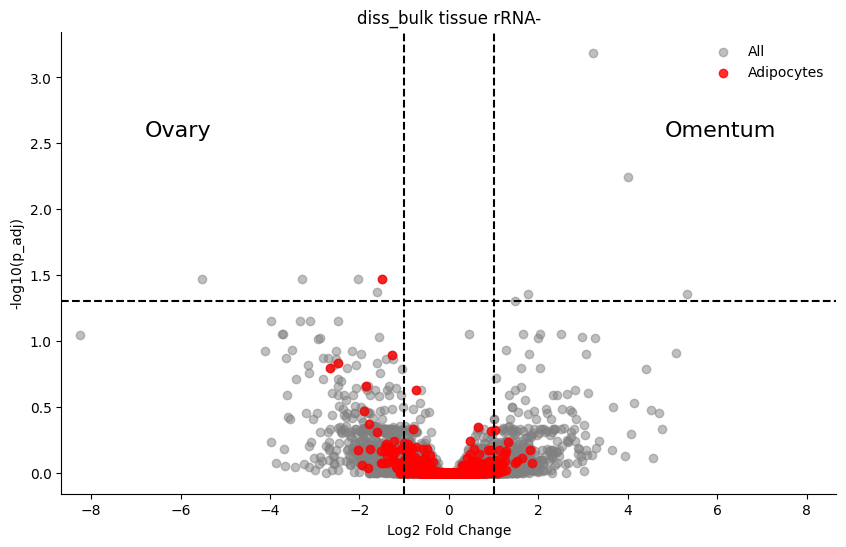

In [25]:
# Volcano plot

df = res.dropna(subset=["log2FoldChange", "padj"])
df = df[df["baseMean"] > 10]

# Create the volcano plot
fig, ax = plt.subplots(figsize=(10, 6))

# Plot all genes
plt.scatter(
    df["log2FoldChange"], -np.log10(df["padj"]), c="grey", label="All", alpha=0.5
)

# # Plot adipocyte genes
plt.scatter(
    df[df.index.isin(list(adipocyte_markers_df.index))]["log2FoldChange"],
    -np.log10(df[df.index.isin(list(adipocyte_markers_df.index))]["padj"]),
    c="red",
    label="Adipocytes",
    alpha=0.8,
)

x_lim = abs(df["log2FoldChange"]).max() * 1.05
plt.xlim([-x_lim, x_lim])
y_lim = -(np.log10(df["padj"]).min())

# # Add labels and title
plt.xlabel("Log2 Fold Change")
plt.ylabel("-log10(p_adj)")
plt.title(f"{DATA_TYPE} tissue rRNA-")

plt.text(-x_lim * 0.7, y_lim * 0.8, "Ovary", size=16, ha="center")
plt.text(x_lim * 0.7, y_lim * 0.8, "Omentum", size=16, ha="center")

# # Add horizontal line for significance threshold
plt.axhline(y=-np.log10(0.05), color="black", linestyle="--")

# # Add vertical lines for fold change threshold (optional)
plt.axvline(x=-1, color="black", linestyle="--")
plt.axvline(x=1, color="black", linestyle="--")

plt.legend(frameon=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

In [68]:
figname = f"volcano_plot_ovary_omentum_{DATA_TYPE}_rrna-"
fig.savefig(figname + ".png", bbox_inches="tight")
fig.savefig(figname + ".pdf", bbox_inches="tight")